# Mechanism-aware drug response prediction - Feature Set Construction & Model Development

## C. MODEL DEVELOPMENT ENVIRONMENT SETUP

Prepare the modeling workflow by setting paths, importing machine-learning libraries, defining reproducibility settings, configuring model parameters, and creating result folders for downstream multi-omics drug-response prediction.

In [6]:
from pathlib import Path
import json
import os
import time
import warnings

PROJECT_DIR = Path.cwd()
MPLCONFIG_DIR = PROJECT_DIR / "data" / "model_results" / ".matplotlib"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNetCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    print(f"XGBoost unavailable, skipping {exc}")

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LGBMRegressor = None
    LIGHTGBM_AVAILABLE = False
    print(f"LightGBM unavailable, skipping {exc}")

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "data" / "model_results"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [7]:
RUN_FULL_MODELING = False
N_ANALYSIS_COMPOUNDS = 12
N_SPLITS = 5

MIN_DRUG_COVERAGE = 250
MIN_AAC_STD = 0.03
TOP_N_IMPORTANCE_FEATURES = 50
QUICK_MAX_FEATURES_PER_LAYER = 1000

if RUN_FULL_MODELING:
    ELASTICNET_ALPHAS = np.logspace(-3, 0.5, 12)
    ELASTICNET_L1_RATIOS = [0.2, 0.5, 0.8]
else:
    ELASTICNET_ALPHAS = np.logspace(-3, 0.5, 5)
    ELASTICNET_L1_RATIOS = [0.5]

RIDGE_ALPHAS = np.logspace(-2, 4, 20) if RUN_FULL_MODELING else np.logspace(-1, 3, 8)
SELECT_K_FEATURES = 750 if RUN_FULL_MODELING else 250

XGBOOST_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "reg_lambda": 5,
    "reg_alpha": 1,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "tree_method": "hist",
    "verbosity": 0,
}
if not RUN_FULL_MODELING:
    XGBOOST_PARAMS.update({"n_estimators": 120, "max_depth": 2, "colsample_bytree": 0.7})

LIGHTGBM_PARAMS = {
    "n_estimators": 300,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "max_depth": -1,
    "min_child_samples": 15,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "reg_lambda": 5,
    "reg_alpha": 1,
    "objective": "regression",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}
if not RUN_FULL_MODELING:
    LIGHTGBM_PARAMS.update({"n_estimators": 160, "num_leaves": 9, "colsample_bytree": 0.7})

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print(f"PROJECT_DIR   {PROJECT_DIR}")
print(f"PROCESSED_DIR {PROCESSED_DIR}")
print(f"RESULTS_DIR   {RESULTS_DIR}")
print(f"XGBoost available {XGBOOST_AVAILABLE}")
print(f"LightGBM available {LIGHTGBM_AVAILABLE}")


PROJECT_DIR   /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC
PROCESSED_DIR /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/data/processed
RESULTS_DIR   /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/data/model_results
XGBoost available True
LightGBM available True


## 1. Load and align processed matrices


In [8]:
omics_raw = {}
layer_files = {
    "expr": "expression",
    "mut": "mutations",
    "cnv": "cnv",
    "meth": "methylation",
    "prot": "proteomics",
}
for key, fname in layer_files.items():
    path = PROCESSED_DIR / f"{fname}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing processed file {path}")
    df = pd.read_parquet(path)
    if "ModelID" in df.columns:
        df = df.set_index("ModelID")
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    omics_raw[key] = df

drug_response_raw = pd.read_parquet(PROCESSED_DIR / "drug_response.parquet")
if "ModelID" in drug_response_raw.columns:
    drug_response_raw = drug_response_raw.set_index("ModelID")

meta_path = PROCESSED_DIR / "cell_metadata.parquet"
cell_metadata = pd.read_parquet(meta_path) if meta_path.exists() else None
if cell_metadata is not None and "ModelID" in cell_metadata.columns:
    cell_metadata = cell_metadata.set_index("ModelID")

all_ids = sorted(set().union(*(set(df.index) for df in omics_raw.values()), set(drug_response_raw.index)))
availability = pd.DataFrame(index=all_ids)
for layer_name, df in omics_raw.items():
    availability[layer_name] = availability.index.isin(df.index)
availability["drug_response"] = availability.index.isin(drug_response_raw.index)

common_ids = sorted(set.intersection(*(set(df.index) for df in omics_raw.values()), set(drug_response_raw.index)))
omics = {name: df.loc[common_ids].sort_index().fillna(0.0).astype(np.float32) for name, df in omics_raw.items()}
drug_response = drug_response_raw.loc[common_ids].sort_index().astype(np.float32)

if cell_metadata is not None:
    cell_metadata = cell_metadata.loc[cell_metadata.index.intersection(common_ids)].sort_index()
    lineage_features = pd.get_dummies(
        cell_metadata.reindex(common_ids)["OncotreeLineage"].fillna("Unknown"),
        prefix="lineage",
        dtype=np.float32,
    )
    lineage_features.columns = [f"meta::{col}" for col in lineage_features.columns]
    lineage_features = lineage_features.loc[drug_response.index]
else:
    lineage_features = pd.DataFrame(index=drug_response.index)

for name, df in omics.items():
    assert df.index.equals(drug_response.index), f"Index mismatch for {name}"

feature_counts = pd.Series({name: df.shape[1] for name, df in omics.items()}, name="n_features")
shape_summary = pd.DataFrame({
    "n_cell_lines": {name: df.shape[0] for name, df in omics.items()},
    "n_features": feature_counts,
})

print("Aligned omics shapes")
display(shape_summary)
print(f"Drug response shape {drug_response.shape}")
print(f"Shared cell lines {len(common_ids)}")
print(f"Lineage metadata features {lineage_features.shape[1]}")


Aligned omics shapes


,n_cell_lines,n_features
expr,389,4999
mut,389,1000
cnv,389,4999
meth,389,5000
prot,389,3000


Drug response shape (389, 544)
Shared cell lines 389
Lineage metadata features 24


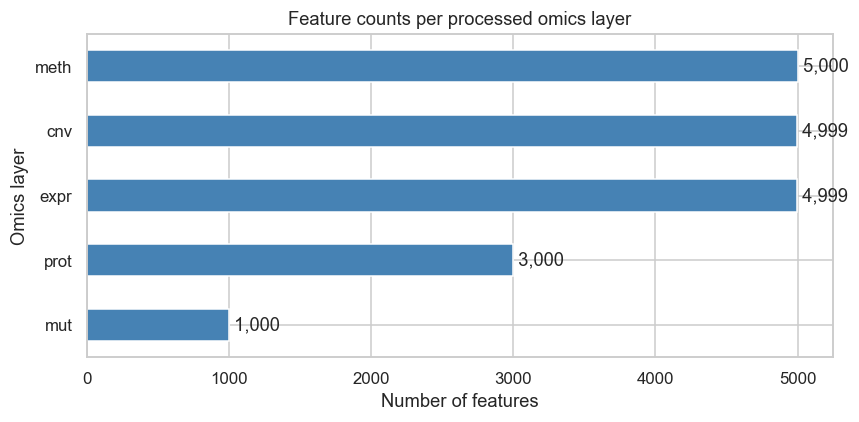

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
feature_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of features")
ax.set_ylabel("Omics layer")
ax.set_title("Feature counts per processed omics layer")
for i, value in enumerate(feature_counts.sort_values()):
    ax.text(value, i, f" {value:,}", va="center")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "feature_counts_per_omics_layer.png", dpi=180, bbox_inches="tight")
plt.show()


## 2. Select eligible drug targets

Compute drug response statistics for each compound, including coverage (number of cell lines tested), mean AAC, variability (AAC standard deviation), and response range. Compounds with sufficient coverage and response variability were selected for downstream modeling, ensuring that only informative and well-represented drugs were included in the analysis.



In [7]:
drug_summary = pd.DataFrame({
    "compound": drug_response.columns,
    "coverage": drug_response.notna().sum(axis=0).values,
    "aac_mean": drug_response.mean(axis=0, skipna=True).values,
    "aac_std": drug_response.std(axis=0, skipna=True).values,
    "aac_min": drug_response.min(axis=0, skipna=True).values,
    "aac_max": drug_response.max(axis=0, skipna=True).values,
}).set_index("compound")

drug_summary["eligible"] = (
    (drug_summary["coverage"] >= MIN_DRUG_COVERAGE)
    & (drug_summary["aac_std"] >= MIN_AAC_STD)
)
drug_summary["selection_score"] = drug_summary["coverage"] * drug_summary["aac_std"]

eligible_compounds = (
    drug_summary.loc[drug_summary["eligible"]]
    .sort_values(["selection_score", "coverage", "aac_std"], ascending=False)
)

eligible_compounds.reset_index().to_csv(RESULTS_DIR / "eligible_compounds.csv", index=False)

print(f"Total compounds {drug_response.shape[1]:,}")
print(f"Eligible compounds {len(eligible_compounds):,}")
display(eligible_compounds.head(15))


Total compounds 544
Eligible compounds 410


,coverage,aac_mean,aac_std,aac_min,aac_max,eligible,selection_score
compound,,,,,,,
Vincristine,374,0.497399,0.231008,0.000000,0.987693,True,86.397079
SB-743921,353,0.585168,0.242272,0.030407,0.987152,True,85.522023
Oligomycin A,339,0.385379,0.240682,0.000000,0.981403,True,81.591346
BI-2536,359,0.518972,0.211384,0.000000,0.990110,True,75.886743
"1S,3R-RSL-3",366,0.450432,0.204804,0.013289,0.924021,True,74.958423
docetaxel:tanespimycin (2:1 mol/mol),360,0.586285,0.200101,0.018907,0.983458,True,72.036538
Leptomycin B,373,0.720565,0.185001,0.034846,0.984921,True,69.005379
KX2-391,355,0.405456,0.193936,0.000000,0.921312,True,68.847361
ML210,320,0.319800,0.214800,0.000000,0.872048,True,68.736124


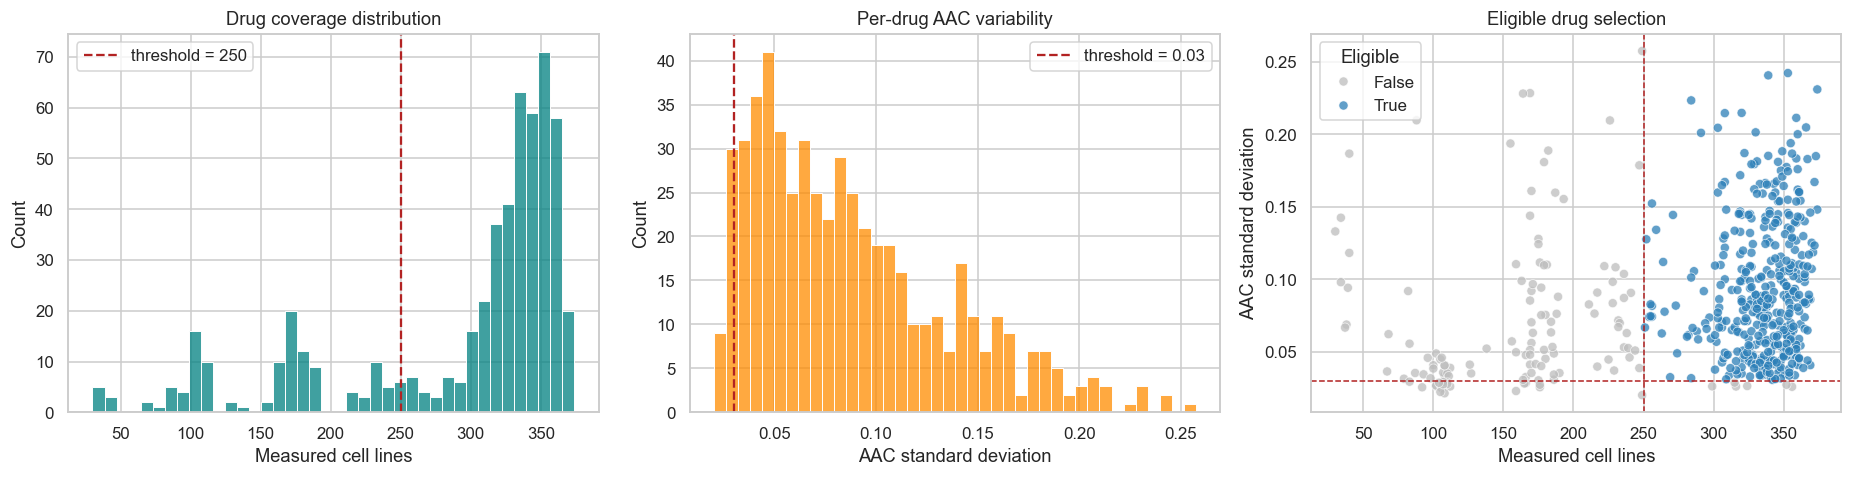

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.histplot(drug_summary["coverage"], bins=40, ax=axes[0], color="teal")
axes[0].axvline(MIN_DRUG_COVERAGE, color="firebrick", linestyle="--", label=f"threshold = {MIN_DRUG_COVERAGE}")
axes[0].set_xlabel("Measured cell lines")
axes[0].set_title("Drug coverage distribution")
axes[0].legend()

sns.histplot(drug_summary["aac_std"], bins=40, ax=axes[1], color="darkorange")
axes[1].axvline(MIN_AAC_STD, color="firebrick", linestyle="--", label=f"threshold = {MIN_AAC_STD}")
axes[1].set_xlabel("AAC standard deviation")
axes[1].set_title("Per-drug AAC variability")
axes[1].legend()

sns.scatterplot(
    data=drug_summary.reset_index(),
    x="coverage",
    y="aac_std",
    hue="eligible",
    palette={False: "#bdbdbd", True: "#2c7fb8"},
    alpha=0.75,
    ax=axes[2],
)
axes[2].axvline(MIN_DRUG_COVERAGE, color="firebrick", linestyle="--", linewidth=1)
axes[2].axhline(MIN_AAC_STD, color="firebrick", linestyle="--", linewidth=1)
axes[2].set_xlabel("Measured cell lines")
axes[2].set_ylabel("AAC standard deviation")
axes[2].set_title("Eligible drug selection")
axes[2].legend(title="Eligible")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "eligible_drug_selection.png", dpi=180, bbox_inches="tight")
plt.show()


Drug selection was based on both data availability and response variability. Compounds tested in at least 250 cell lines and exhibiting an AAC standard deviation of at least 0.03 were retained, ensuring that downstream models are trained on sufficiently represented and biologically informative drug-response profiles.

## D. FEATURE SETS CONSTRUCTION

Feature sets were generated for individual omics layers as well as integrated multi-omics representations using early feature fusion. Additional feature sets incorporating lineage metadata were created to evaluate the contribution of cancer-type information to predictive performance.

In [10]:
SINGLE_LAYERS = ["expr", "mut", "cnv", "meth", "prot"]
SIGNAL_FUSION_LAYERS = ["expr", "meth", "prot"]
LAYER_LABELS = {
    "expr": "Expression",
    "mut": "Mutations",
    "cnv": "CNV",
    "meth": "Methylation",
    "prot": "Proteomics",
    "multiomics": "Multi-omics",
    "multiomics_plus_lineage": "Multi-omics + lineage",
    "signal_multiomics": "Expression + methylation + proteomics",
    "signal_multiomics_plus_lineage": "Expression + methylation + proteomics + lineage",
    "expr_plus_lineage": "Expression + lineage",
    "meta": "Lineage metadata",
}

omics_for_modeling = omics if RUN_FULL_MODELING else {
    name: df.iloc[:, :min(QUICK_MAX_FEATURES_PER_LAYER, df.shape[1])].copy()
    for name, df in omics.items()
}

feature_sets = {name: omics_for_modeling[name] for name in SINGLE_LAYERS}
early_fusion = pd.concat(
    [omics_for_modeling[name].rename(columns=lambda c, n=name: f"{n}::{c}") for name in SINGLE_LAYERS],
    axis=1,
)
signal_fusion = pd.concat(
    [omics_for_modeling[name].rename(columns=lambda c, n=name: f"{n}::{c}") for name in SIGNAL_FUSION_LAYERS],
    axis=1,
)
feature_sets["early_fusion"] = early_fusion
feature_sets["signal_fusion"] = signal_fusion

if not lineage_features.empty:
    aligned_lineage = lineage_features.loc[early_fusion.index]
    feature_sets["early_fusion_lineage"] = pd.concat([early_fusion, aligned_lineage], axis=1)
    feature_sets["signal_fusion_lineage"] = pd.concat([signal_fusion, aligned_lineage], axis=1)
    feature_sets["expr_lineage"] = pd.concat(
        [
            omics_for_modeling["expr"].rename(columns=lambda c: f"expr::{c}"),
            aligned_lineage,
        ],
        axis=1,
    )

print("Feature set shapes")
if not RUN_FULL_MODELING:
    print(f"Quick mode feature cap per layer {QUICK_MAX_FEATURES_PER_LAYER}")
for name, df in feature_sets.items():
    print(f"  {name:<23} {df.shape[0]:>4,} x {df.shape[1]:>6,}")

assert feature_sets["early_fusion"].columns.str.contains("::", regex=False).all()
assert feature_sets["signal_fusion"].columns.str.contains("::", regex=False).all()
assert not set(drug_response.columns).intersection(feature_sets["early_fusion"].columns)
assert not set(drug_response.columns).intersection(feature_sets["signal_fusion"].columns)
if "early_fusion_lineage" in feature_sets:
    assert not set(drug_response.columns).intersection(feature_sets["early_fusion_lineage"].columns)
if "signal_fusion_lineage" in feature_sets:
    assert not set(drug_response.columns).intersection(feature_sets["signal_fusion_lineage"].columns)


Feature set shapes
Quick mode feature cap per layer 1000
  expr                     389 x  1,000
  mut                      389 x  1,000
  cnv                      389 x  1,000
  meth                     389 x  1,000
  prot                     389 x  1,000
  early_fusion             389 x  5,000
  signal_fusion            389 x  3,000
  early_fusion_lineage     389 x  5,024
  signal_fusion_lineage    389 x  3,024
  expr_lineage             389 x  1,024


These are construct modeling inputs from individual omics layers and integrated multi-omics representations. Early fusion combines features across modalities (multi-omics), while lineage-enhanced variants test whether cancer-type information improves drug-response prediction.

## E. MODEL DEVELOPMENT

## 1. Modeling setup

Define the machine learning models and integration strategies used for drug-response prediction. Models range from interpretable linear methods (ElasticNet, Ridge) to ensemble learners (XGBoost, LightGBM), while strategies compare single-omics, multi-omics fusion, and lineage-augmented representations.

In [12]:
MODEL_BUILDERS = {
    "ElasticNet": lambda: make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        ElasticNetCV(
            l1_ratio=ELASTICNET_L1_RATIOS,
            alphas=ELASTICNET_ALPHAS,
            cv=3,
            max_iter=10000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            selection="random",
        ),
    ),
    "RidgeCV": lambda: make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        RidgeCV(alphas=RIDGE_ALPHAS),
    ),
    "RidgeSelectK": lambda: make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        SelectKBest(score_func=f_regression, k=SELECT_K_FEATURES),
        RidgeCV(alphas=RIDGE_ALPHAS),
    ),
}
if XGBOOST_AVAILABLE:
    MODEL_BUILDERS["XGBoost"] = lambda: XGBRegressor(**XGBOOST_PARAMS)
if LIGHTGBM_AVAILABLE:
    MODEL_BUILDERS["LightGBM"] = lambda: LGBMRegressor(**LIGHTGBM_PARAMS)

MODEL_FAMILIES = ["ElasticNet", "RidgeCV", "RidgeSelectK"]
if XGBOOST_AVAILABLE:
    MODEL_FAMILIES.append("XGBoost")
if LIGHTGBM_AVAILABLE:
    MODEL_FAMILIES.append("LightGBM")

STRATEGY_LABELS = {
    "early_fusion": "Early fusion",
    "late_fusion": "Late fusion",
    "metadata_augmented": "Expression + lineage",
    "early_fusion_lineage": "Early fusion + lineage",
    "signal_fusion": "Focused fusion",
    "signal_fusion_lineage": "Focused fusion + lineage",
    "learned_late_fusion": "Learned late fusion",
    "pathway_modules": "Pathway modules",
    "pathway_modules_lineage": "Pathway + lineage",
}

print("Model families")
print(", ".join(MODEL_FAMILIES))


Model families
ElasticNet, RidgeCV, RidgeSelectK, XGBoost, LightGBM


## 2. Scoring helper

Evaluate model predictions using correlation- and error-based metrics. Returns Pearson and Spearman correlations, RMSE, MAE, and R² to assess both predictive accuracy and agreement with observed drug responses.

In [13]:
def score_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) == 0:
        return {"pearson": np.nan, "spearman": np.nan, "rmse": np.nan, "mae": np.nan, "r2": np.nan}
    if len(y_true) < 3 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = spearman = np.nan
    else:
        pearson = float(pearsonr(y_true, y_pred).statistic)
        spearman = float(spearmanr(y_true, y_pred).statistic)
    return {
        "pearson": pearson,
        "spearman": spearman,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
    }


## 3. Cross validation 

### 3.1 Cross validation helper

Run cross-validation for one model, compound, and feature set. For each fold, the function trains the model, evaluates prediction performance, stores test predictions, and extracts feature/layer importance for interpretation.

In [14]:
def run_cv_model(model_family, X, y, folds, compound, strategy, omics_layer):
    metric_records, prediction_records = [], []
    feature_importance_records, layer_importance_records = [], []
    feature_names = X.columns.to_numpy()

    for fold_id, (train_ids, test_ids) in enumerate(folds, start=1):
        X_train = X.loc[train_ids].to_numpy(dtype=np.float32, copy=False)
        X_test = X.loc[test_ids].to_numpy(dtype=np.float32, copy=False)
        y_train = y.loc[train_ids].to_numpy(dtype=np.float32)
        y_test = y.loc[test_ids].to_numpy(dtype=np.float32)

        model = MODEL_BUILDERS[model_family]()
        model.fit(X_train, y_train)
        y_pred = np.asarray(model.predict(X_test), dtype=float).ravel()

        metric_records.append({
            "compound": compound,
            "model_family": model_family,
            "strategy": strategy,
            "omics_layer": omics_layer,
            "fold": fold_id,
            "n_train": len(train_ids),
            "n_test": len(test_ids),
            **score_predictions(y_test, y_pred),
        })
        prediction_records.extend({
            "compound": compound,
            "model_family": model_family,
            "strategy": strategy,
            "omics_layer": omics_layer,
            "fold": fold_id,
            "ModelID": model_id,
            "y_true": float(obs),
            "y_pred": float(pred),
        } for model_id, obs, pred in zip(test_ids, y_test, y_pred))

        if model_family == "ElasticNet":
            values = np.abs(model.named_steps["elasticnetcv"].coef_)
        elif model_family == "RidgeCV":
            values = np.abs(model.named_steps["ridgecv"].coef_).ravel()
        elif model_family == "RidgeSelectK":
            selector = model.named_steps["selectkbest"]
            values = np.zeros(len(feature_names), dtype=float)
            values[selector.get_support()] = np.abs(model.named_steps["ridgecv"].coef_).ravel()
        elif model_family in {"XGBoost", "LightGBM"}:
            values = np.asarray(model.feature_importances_, dtype=float)
        else:
            values = np.zeros(len(feature_names), dtype=float)

        feature_df = pd.DataFrame({
            "feature": feature_names.astype(str),
            "omics_layer": [str(f).split("::", 1)[0] if "::" in str(f) else omics_layer for f in feature_names],
            "importance": np.asarray(values, dtype=float).ravel(),
        }).sort_values("importance", ascending=False)

        layer_df = (
            feature_df.groupby("omics_layer", as_index=False)["importance"]
            .sum()
            .rename(columns={"importance": "raw_importance"})
        )
        total = layer_df["raw_importance"].sum()
        layer_df["importance_fraction"] = layer_df["raw_importance"] / total if total > 0 else np.nan

        top_features = feature_df.head(TOP_N_IMPORTANCE_FEATURES).assign(
            compound=compound,
            model_family=model_family,
            strategy=strategy,
            omics_layer_model=omics_layer,
            fold=fold_id,
        )
        feature_importance_records.extend(top_features[
            ["compound", "model_family", "strategy", "omics_layer_model", "fold", "feature", "omics_layer", "importance"]
        ].to_dict("records"))

        layer_records = layer_df.assign(
            compound=compound,
            model_family=model_family,
            strategy=strategy,
            omics_layer_model=omics_layer,
            fold=fold_id,
        )
        layer_importance_records.extend(layer_records[
            ["compound", "model_family", "strategy", "omics_layer_model", "fold", "omics_layer", "raw_importance", "importance_fraction"]
        ].to_dict("records"))

    return metric_records, prediction_records, feature_importance_records, layer_importance_records


### 3.2 Cross validated modeling

Run cross-validated drug-response prediction across selected compounds, models, and feature sets. For each compound, models are trained/evaluated on shared folds, including single-omics, early-fusion, focused-fusion, lineage-augmented, and late-fusion strategies; metrics, predictions, and importance outputs are saved for analysis.


In [18]:
modeling_compounds = eligible_compounds.index.to_list()
if not RUN_FULL_MODELING:
    modeling_compounds = modeling_compounds[:N_ANALYSIS_COMPOUNDS]

all_metrics, all_predictions = [], []
all_feature_importance, all_layer_importance = [], []

evaluation_specs = [(layer_name, "single_omics", layer_name) for layer_name in SINGLE_LAYERS]
evaluation_specs.extend([
    ("early_fusion", "early_fusion", "multiomics"),
    ("signal_fusion", "signal_fusion", "signal_multiomics"),
])
if "early_fusion_lineage" in feature_sets:
    evaluation_specs.append(("early_fusion_lineage", "early_fusion_lineage", "multiomics_plus_lineage"))
if "signal_fusion_lineage" in feature_sets:
    evaluation_specs.append(("signal_fusion_lineage", "signal_fusion_lineage", "signal_multiomics_plus_lineage"))
if "expr_lineage" in feature_sets:
    evaluation_specs.append(("expr_lineage", "metadata_augmented", "expr_plus_lineage"))


### 3.3 Base model cross validation


In [19]:
started = time.time()
for compound_i, compound in enumerate(modeling_compounds, start=1):
    y = drug_response[compound].dropna()
    valid_ids = y.index.to_numpy()
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    folds = [(valid_ids[tr], valid_ids[te]) for tr, te in kf.split(valid_ids)]
    print(f"[{compound_i:>3}/{len(modeling_compounds):>3}] {compound} measured n {len(y)}")

    for model_family in MODEL_FAMILIES:
        family_predictions = []
        for feature_key, strategy_name, omics_layer_name in evaluation_specs:
            m, p, f, l = run_cv_model(
                model_family,
                feature_sets[feature_key],
                y,
                folds,
                compound,
                strategy_name,
                omics_layer_name,
            )
            all_metrics.extend(m)
            all_predictions.extend(p)
            all_feature_importance.extend(f)
            all_layer_importance.extend(l)
            if strategy_name == "single_omics":
                family_predictions.extend(p)

        single_pred_df = pd.DataFrame(family_predictions)
        if not single_pred_df.empty:
            averaged = (
                single_pred_df.groupby(["fold", "ModelID"], as_index=False)
                .agg(y_true=("y_true", "first"), y_pred=("y_pred", "mean"))
            )
            for fold_id, fold_df in averaged.groupby("fold"):
                all_predictions.extend({
                    "compound": compound,
                    "model_family": model_family,
                    "strategy": "late_fusion",
                    "omics_layer": "multiomics",
                    "fold": int(fold_id),
                    "ModelID": row.ModelID,
                    "y_true": float(row.y_true),
                    "y_pred": float(row.y_pred),
                } for row in fold_df.itertuples())
                all_metrics.append({
                    "compound": compound,
                    "model_family": model_family,
                    "strategy": "late_fusion",
                    "omics_layer": "multiomics",
                    "fold": int(fold_id),
                    "n_train": np.nan,
                    "n_test": len(fold_df),
                    **score_predictions(fold_df["y_true"], fold_df["y_pred"]),
                })

print(f"Finished {len(modeling_compounds)} compounds in {(time.time() - started) / 60:.1f} minutes")


[  1/ 12] Vincristine measured n 374


/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-package

[  2/ 12] SB-743921 measured n 353


/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-package

[  3/ 12] Oligomycin A measured n 339


...

/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-package

[ 12/ 12] Clofarabine measured n 330


/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-package

Finished 12 compounds in 10.6 minutes


/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 3.4 Base model outputs


In [ ]:
cv_metrics = pd.DataFrame(all_metrics)
cv_predictions = pd.DataFrame(all_predictions)
feature_importance = pd.DataFrame(all_feature_importance)
layer_importance = pd.DataFrame(all_layer_importance)

cv_metrics.to_csv(RESULTS_DIR / "cv_metrics.csv", index=False)
cv_predictions.to_csv(RESULTS_DIR / "cv_predictions.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(RESULTS_DIR / "feature_importance_all_models.csv", index=False)
if not layer_importance.empty:
    layer_importance.to_csv(RESULTS_DIR / "omics_layer_importance.csv", index=False)

print("Saved modeling outputs")
for path in sorted(RESULTS_DIR.glob("*.csv")):
    print(f"  {path.name:<38} {path.stat().st_size / 1024:>9.1f} KB")

display(cv_metrics.head())


Saved modeling outputs
  cv_metrics.csv                             508.6 KB
  cv_predictions.csv                       23194.5 KB
  eligible_compounds.csv                      31.8 KB
  feature_importance_all_models.csv        12692.5 KB
  omics_layer_importance.csv                 669.7 KB


,compound,model_family,strategy,omics_layer,fold,n_train,n_test,pearson,spearman,rmse,mae,r2
0,Vincristine,ElasticNet,single_omics,expr,1,299.0,75,0.546394,0.565576,0.220866,0.179750,0.276348
1,Vincristine,ElasticNet,single_omics,expr,2,299.0,75,0.618546,0.547824,0.196050,0.159017,0.352513
2,Vincristine,ElasticNet,single_omics,expr,3,299.0,75,0.661300,0.582447,0.148553,0.122468,0.431307
3,Vincristine,ElasticNet,single_omics,expr,4,299.0,75,0.638627,0.603642,0.181702,0.144928,0.397039
4,Vincristine,ElasticNet,single_omics,expr,5,300.0,74,0.550332,0.427353,0.175461,0.147071,0.298959


## E. LATE FUSION INTEGRATION

Implement learned late fusion by first training separate single-omics models, then using their predictions as inputs to a second-stage meta-model. The meta-model learns non-negative weights for each omics layer, allowing us to evaluate which modalities contribute most to final drug-response prediction.


## 1. Late Fusion

In [4]:
learned_metrics, learned_predictions, learned_weights = [], [], []
stacking_specs = [
    ("RidgeCV", "RidgeCV+PositiveStack"),
    ("RidgeSelectK", "RidgeSelectK+PositiveStack"),
]


## 2. Learned fusion models


In [5]:
for base_family, model_label in stacking_specs:
    for compound_i, compound in enumerate(modeling_compounds, start=1):
        y = drug_response[compound].dropna()
        valid_ids = y.index.to_numpy()
        kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        folds = [(valid_ids[tr], valid_ids[te]) for tr, te in kf.split(valid_ids)]
        print(f"[{model_label} {compound_i:>3}/{len(modeling_compounds):>3}] {compound} measured n {len(y)}")

        for fold_id, (train_ids, test_ids) in enumerate(folds, start=1):
            z_train = pd.DataFrame(index=train_ids, columns=SINGLE_LAYERS, dtype=float)
            z_test = pd.DataFrame(index=test_ids, columns=SINGLE_LAYERS, dtype=float)
            inner_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE + fold_id)

            for layer_name in SINGLE_LAYERS:
                X = feature_sets[layer_name]
                for inner_train_idx, inner_val_idx in inner_cv.split(train_ids):
                    inner_train_ids = train_ids[inner_train_idx]
                    inner_val_ids = train_ids[inner_val_idx]
                    base_model = MODEL_BUILDERS[base_family]()
                    base_model.fit(
                        X.loc[inner_train_ids].to_numpy(dtype=np.float32, copy=False),
                        y.loc[inner_train_ids].to_numpy(dtype=np.float32),
                    )
                    z_train.loc[inner_val_ids, layer_name] = np.asarray(
                        base_model.predict(X.loc[inner_val_ids].to_numpy(dtype=np.float32, copy=False)), dtype=float
                    ).ravel()

                final_base_model = MODEL_BUILDERS[base_family]()
                final_base_model.fit(
                    X.loc[train_ids].to_numpy(dtype=np.float32, copy=False),
                    y.loc[train_ids].to_numpy(dtype=np.float32),
                )
                z_test[layer_name] = np.asarray(
                    final_base_model.predict(X.loc[test_ids].to_numpy(dtype=np.float32, copy=False)), dtype=float
                ).ravel()

            meta_model = LinearRegression(positive=True)
            meta_model.fit(z_train.to_numpy(dtype=float), y.loc[train_ids].to_numpy(dtype=float))
            y_pred = np.asarray(meta_model.predict(z_test.to_numpy(dtype=float)), dtype=float).ravel()
            y_test = y.loc[test_ids].to_numpy(dtype=float)

            learned_metrics.append({
                "compound": compound,
                "model_family": model_label,
                "strategy": "learned_late_fusion",
                "omics_layer": "multiomics",
                "fold": fold_id,
                "n_train": len(train_ids),
                "n_test": len(test_ids),
                **score_predictions(y_test, y_pred),
            })
            learned_predictions.extend({
                "compound": compound,
                "model_family": model_label,
                "strategy": "learned_late_fusion",
                "omics_layer": "multiomics",
                "fold": fold_id,
                "ModelID": model_id,
                "y_true": float(obs),
                "y_pred": float(pred),
            } for model_id, obs, pred in zip(test_ids, y_test, y_pred))

            coef = np.asarray(meta_model.coef_, dtype=float).ravel()
            coef_sum = np.abs(coef).sum()
            for layer_name, weight in zip(SINGLE_LAYERS, coef):
                learned_weights.append({
                    "compound": compound,
                    "model_family": model_label,
                    "strategy": "learned_late_fusion",
                    "omics_layer": layer_name,
                    "fold": fold_id,
                    "weight": float(weight),
                    "weight_fraction": float(abs(weight) / coef_sum) if coef_sum > 0 else np.nan,
                })


NameError: name 'modeling_compounds' is not defined

## 3. Learned fusion outputs


In [3]:
learned_metrics = pd.DataFrame(learned_metrics)
learned_predictions = pd.DataFrame(learned_predictions)
learned_weights = pd.DataFrame(learned_weights)

cv_metrics = pd.concat([cv_metrics, learned_metrics], ignore_index=True)
cv_predictions = pd.concat([cv_predictions, learned_predictions], ignore_index=True)
learned_weights.to_csv(RESULTS_DIR / "learned_late_fusion_weights.csv", index=False)
cv_metrics.to_csv(RESULTS_DIR / "cv_metrics.csv", index=False)
cv_predictions.to_csv(RESULTS_DIR / "cv_predictions.csv", index=False)

weight_summary = (
    learned_weights.groupby(["model_family", "omics_layer"], as_index=False)["weight_fraction"]
    .mean()
    .sort_values(["model_family", "weight_fraction"], ascending=[True, False])
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=weight_summary, x="weight_fraction", y="omics_layer", hue="model_family", ax=ax)
ax.set_xlabel("Mean learned weight fraction")
ax.set_ylabel("Omics layer")
ax.set_title("Learned late-fusion omics weights")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "learned_late_fusion_weights.png", dpi=180, bbox_inches="tight")
plt.show()

display(learned_metrics.groupby(["model_family", "strategy", "omics_layer"])[["pearson", "spearman", "rmse", "mae", "r2"]].mean())


NameError: name 'learned_metrics' is not defined

Learned late-fusion models were used to estimate the relative contribution of each omics modality to drug-response prediction. Gene expression consistently received the largest weight (~70%), indicating that it is the primary source of predictive signal, while methylation and proteomics provided smaller complementary contributions. Mutation and CNV data contributed relatively little additional information once other molecular layers were incorporated.

## F. MODEL EVALUATION AND RESULTS

## 1. Aggregate Cross-Validation Results

Aggregate cross-validation outputs to compare model families, omics layers, and multi-omics integration strategies.

### 1.1 Aggregate CV results

In [ ]:
import pandas as pd

cv_metrics = pd.read_csv(RESULTS_DIR / "cv_metrics.csv")

print(cv_metrics.shape)
display(cv_metrics.head())

NameError: name 'RESULTS_DIR' is not defined

## 8. Pathway and module features


In [ ]:
PATHWAY_MODULE_RECORDS = [
    (
        "cell_cycle_mitosis",
        "Reactome Cell Cycle Mitotic and MSigDB Hallmark G2M Checkpoint",
        "Captures proliferation, mitotic checkpoint, and anti-mitotic drug response biology",
        "AURKA AURKB BUB1 BUB1B CCNA2 CCNB1 CCNB2 CDC20 CDC25C CDK1 CENPA CENPE CENPF CHEK1 FOXM1 KIF11 KIF20A MKI67 PLK1 TOP2A".split(),
    ),
    (
        "microtubule_spindle",
        "MSigDB Hallmark Mitotic Spindle and Reactome mitotic spindle checkpoint biology",
        "Captures tubulin, kinesin, spindle assembly, and microtubule-targeting drug biology",
        "TUBA1A TUBA1B TUBB TUBB3 TUBB4B MAP2 MAP4 KIF2C KIF11 KIF14 KIF20A KIF23 KIFC1 AURKA AURKB PLK1 NUSAP1 TPX2".split(),
    ),
    (
        "apoptosis",
        "MSigDB Hallmark Apoptosis and Reactome Apoptosis",
        "Captures intrinsic and extrinsic cell death response relevant to drug sensitivity",
        "BAX BAK1 BCL2 BCL2L1 BCL2L11 BID CASP3 CASP7 CASP8 CASP9 FAS FADD MCL1 PMAIP1 TNFRSF10B XIAP".split(),
    ),
    (
        "dna_damage_repair",
        "MSigDB Hallmark DNA Repair and Reactome DNA Repair",
        "Captures DNA damage response and repair dependency relevant to genotoxic therapy",
        "ATM ATR BRCA1 BRCA2 CHEK1 CHEK2 ERCC1 FANCD2 MLH1 MSH2 MSH6 PARP1 RAD51 TP53 XRCC1".split(),
    ),
    (
        "mapk_signaling",
        "Reactome RAF MAP kinase cascade and canonical RAS RAF MEK ERK signaling",
        "Captures growth factor signaling and MAPK pathway oncogene dependency",
        "BRAF RAF1 KRAS NRAS HRAS MAP2K1 MAP2K2 MAPK1 MAPK3 DUSP4 DUSP6 EGFR ERBB2 FGFR1 FGFR2 MET".split(),
    ),
    (
        "pi3k_akt_mtor",
        "MSigDB Hallmark PI3K AKT MTOR Signaling and Reactome PI3K AKT signaling",
        "Captures survival, growth, and mTOR pathway dependency",
        "PIK3CA PIK3CB PIK3R1 PTEN AKT1 AKT2 MTOR RICTOR RPTOR TSC1 TSC2 PDPK1 FOXO3 RPS6KB1".split(),
    ),
    (
        "emt_adhesion",
        "MSigDB Hallmark Epithelial Mesenchymal Transition and adhesion marker biology",
        "Captures lineage plasticity, invasion, matrix, and adhesion-associated drug response",
        "VIM CDH1 CDH2 FN1 SNAI1 SNAI2 TWIST1 ZEB1 ZEB2 ITGA5 ITGB1 MMP2 MMP9 TGFB1 TGFBI".split(),
    ),
    (
        "oxidative_stress_ferroptosis",
        "FerrDb ferroptosis regulators and oxidative stress response marker biology",
        "Captures lipid peroxidation, iron handling, antioxidant defense, and ferroptosis response",
        "ACSL4 AIFM2 FSP1 GPX4 GCLC GCLM HMOX1 KEAP1 NFE2L2 SLC7A11 TFRC FTH1 FTL NQO1".split(),
    ),
    (
        "proteasome_er_stress",
        "Reactome Unfolded Protein Response and proteasome stress biology",
        "Captures proteasome, ER stress, and unfolded protein response mechanisms",
        "PSMA1 PSMA2 PSMA3 PSMB5 PSMB7 PSMC1 PSMD1 HSPA5 DDIT3 ATF4 ATF6 XBP1 ERN1 EIF2AK3".split(),
    ),
    (
        "chromatin_hdac",
        "Chromatin regulator and epigenetic drug target marker biology",
        "Captures HDAC, BET, PRC2, and DNA methylation regulation relevant to epigenetic drugs",
        "HDAC1 HDAC2 HDAC3 HDAC6 EP300 CREBBP BRD2 BRD4 EZH2 SUZ12 DNMT1 DNMT3A DNMT3B KDM1A".split(),
    ),
    (
        "drug_transport_metabolism",
        "ABC SLC transporter and CYP CES metabolism marker biology",
        "Captures drug efflux, uptake, and metabolism mechanisms that can alter measured response",
        "ABCB1 ABCC1 ABCC2 ABCG2 CYP3A4 CYP2D6 CYP2C8 CES1 CES2 SLC22A1 SLC22A3 SLC29A1 SLCO1B1".split(),
    ),
    (
        "receptor_tyrosine_kinase",
        "Reactome Signaling by Receptor Tyrosine Kinases and cancer RTK pathway curation",
        "Captures growth factor receptor signaling through EGFR ERBB MET ALK ROS RET NTRK FGFR KIT and PDGFR families",
        "EGFR ERBB2 ERBB3 ERBB4 MET ALK ROS1 RET NTRK1 NTRK2 FGFR1 FGFR2 FGFR3 KIT PDGFRA PDGFRB".split(),
    ),
]

pathway_module_definitions = pd.DataFrame([
    {
        "module": module,
        "source_basis": source_basis,
        "rationale": rationale,
        "n_genes": len(genes),
    }
    for module, source_basis, rationale, genes in PATHWAY_MODULE_RECORDS
])
pathway_module_genes = pd.DataFrame([
    {"module": module, "gene": gene}
    for module, source_basis, rationale, genes in PATHWAY_MODULE_RECORDS
    for gene in genes
])
PATHWAY_GENE_SETS = {module: genes for module, source_basis, rationale, genes in PATHWAY_MODULE_RECORDS}

pathway_module_definitions.to_csv(RESULTS_DIR / "pathway_module_definitions.csv", index=False)
pathway_module_genes.to_csv(RESULTS_DIR / "pathway_module_genes.csv", index=False)
display(pathway_module_definitions)


### Pathway feature matrix


In [ ]:
pathway_score_parts = []
pathway_coverage_parts = []
for layer_name in SINGLE_LAYERS:
    df = omics[layer_name]
    gene_to_columns = {}
    for col in df.columns:
        gene = str(col).split("::")[-1].split("_", 1)[0]
        gene_to_columns.setdefault(gene, []).append(col)

    score_df = pd.DataFrame(index=df.index)
    coverage_records = []
    for module_name, genes in PATHWAY_GENE_SETS.items():
        cols = [c for gene in genes for c in gene_to_columns.get(gene, [])]
        score_df[f"{layer_name}::{module_name}"] = df[cols].astype(float).mean(axis=1) if cols else 0.0
        coverage_records.append({
            "omics_layer": layer_name,
            "module": module_name,
            "n_requested_genes": len(genes),
            "n_available_features": len(cols),
        })
    score_df[f"{layer_name}::global_mean"] = df.mean(axis=1)
    score_df[f"{layer_name}::global_abs_mean"] = df.abs().mean(axis=1)
    pathway_score_parts.append(score_df.astype(np.float32))
    pathway_coverage_parts.append(pd.DataFrame(coverage_records))


pathway_features = pd.concat(pathway_score_parts, axis=1).loc[drug_response.index]
pathway_coverage = pd.concat(pathway_coverage_parts, ignore_index=True)
pathway_features_with_lineage = pd.concat([pathway_features, lineage_features], axis=1)

pathway_features.to_csv(RESULTS_DIR / "pathway_module_scores.csv")
pathway_coverage.to_csv(RESULTS_DIR / "pathway_module_feature_coverage.csv", index=False)

print(f"Pathway feature matrix {pathway_features.shape}")
display(pathway_coverage.pivot_table(index="module", columns="omics_layer", values="n_available_features", aggfunc="sum"))


### Pathway coverage plot


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
coverage_pivot = pathway_coverage.pivot_table(
    index="module",
    columns="omics_layer",
    values="n_available_features",
    aggfunc="sum",
).fillna(0)
sns.heatmap(coverage_pivot, cmap="Blues", annot=True, fmt=".0f", linewidths=0.25, ax=ax)
ax.set_xlabel("Omics layer")
ax.set_ylabel("Pathway module")
ax.set_title("Available features per curated pathway module")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "pathway_module_feature_coverage.png", dpi=180, bbox_inches="tight")
plt.show()


### Pathway model comparison


In [ ]:
pathway_metric_records = []
pathway_prediction_records = []
pathway_importance_records = []
pathway_layer_importance_records = []

pathway_model_specs = [
    ("RidgeCV", pathway_features, "pathway_modules"),
    ("RidgeCV", pathway_features_with_lineage, "pathway_modules_lineage"),
]
if LIGHTGBM_AVAILABLE:
    pathway_model_specs.append(("LightGBM", pathway_features, "pathway_modules"))

for model_family, X_pathway, strategy_name in pathway_model_specs:
    for compound in modeling_compounds:
        y = drug_response[compound].dropna()
        valid_ids = y.index.to_numpy()
        kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        folds = [(valid_ids[tr], valid_ids[te]) for tr, te in kf.split(valid_ids)]
        m, p, f, l = run_cv_model(
            model_family, X_pathway, y, folds, compound, strategy_name, "multiomics_pathway"
        )
        pathway_metric_records.extend(m)
        pathway_prediction_records.extend(p)
        pathway_importance_records.extend(f)
        pathway_layer_importance_records.extend(l)

pathway_metrics = pd.DataFrame(pathway_metric_records)
pathway_predictions = pd.DataFrame(pathway_prediction_records)
pathway_feature_importance = pd.DataFrame(pathway_importance_records)
pathway_layer_importance = pd.DataFrame(pathway_layer_importance_records)

cv_metrics = pd.concat([cv_metrics, pathway_metrics], ignore_index=True)
cv_predictions = pd.concat([cv_predictions, pathway_predictions], ignore_index=True)
if not pathway_feature_importance.empty:
    feature_importance = pd.concat([feature_importance, pathway_feature_importance], ignore_index=True)
if not pathway_layer_importance.empty:
    layer_importance = pd.concat([layer_importance, pathway_layer_importance], ignore_index=True)

pathway_metrics.to_csv(RESULTS_DIR / "pathway_model_metrics.csv", index=False)
pathway_predictions.to_csv(RESULTS_DIR / "pathway_model_predictions.csv", index=False)
pathway_feature_importance.to_csv(RESULTS_DIR / "pathway_model_feature_importance.csv", index=False)
cv_metrics.to_csv(RESULTS_DIR / "cv_metrics.csv", index=False)
cv_predictions.to_csv(RESULTS_DIR / "cv_predictions.csv", index=False)
feature_importance.to_csv(RESULTS_DIR / "feature_importance_all_models.csv", index=False)
layer_importance.to_csv(RESULTS_DIR / "omics_layer_importance.csv", index=False)

pathway_summary = (
    pathway_metrics.groupby(["model_family", "strategy"], as_index=False)
    .agg(mean_pearson=("pearson", "mean"), mean_spearman=("spearman", "mean"), mean_rmse=("rmse", "mean"), mean_r2=("r2", "mean"))
    .sort_values("mean_pearson", ascending=False)
)
display(pathway_summary)


### Pathway model plots


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pathway_summary, x="mean_pearson", y="strategy", hue="model_family", ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Mean Pearson correlation")
ax.set_ylabel("Pathway feature strategy")
ax.set_title("Mechanism-aware pathway module models")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "pathway_module_model_performance.png", dpi=180, bbox_inches="tight")
plt.show()

if not pathway_feature_importance.empty:
    pathway_top = (
        pathway_feature_importance.assign(module=lambda d: d["feature"].str.split("::").str[-1])
        .groupby(["model_family", "strategy", "omics_layer", "module"], as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .head(25)
    )
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.barplot(data=pathway_top.sort_values("importance", ascending=True), x="importance", y="module", hue="omics_layer", dodge=False, ax=ax)
    ax.set_xlabel("Mean model-derived importance")
    ax.set_ylabel("Pathway module")
    ax.set_title("Top pathway module features")
    ax.legend(title="Layer", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "top_pathway_module_importance.png", dpi=180, bbox_inches="tight")
    plt.show()


## 9. Model diagnostics


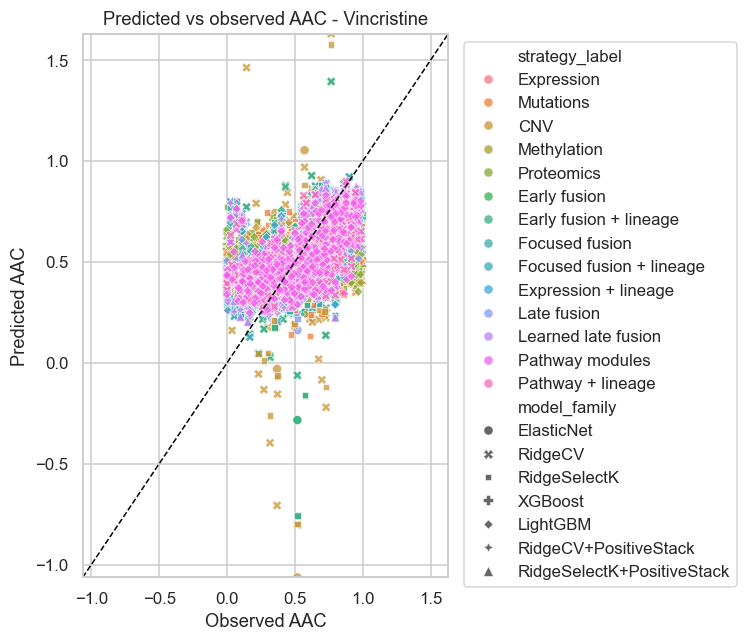

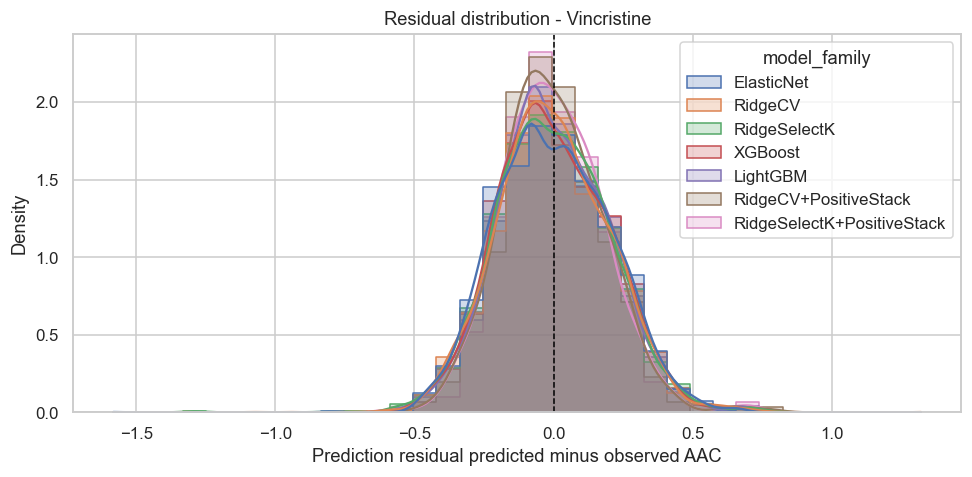

In [12]:
plot_predictions = cv_predictions.copy()
plot_predictions["strategy_label"] = np.where(
    plot_predictions["strategy"].eq("single_omics"),
    plot_predictions["omics_layer"].map(LAYER_LABELS).fillna(plot_predictions["omics_layer"]),
    plot_predictions["strategy"].map(STRATEGY_LABELS).fillna(plot_predictions["strategy"]),
)
plot_predictions["residual"] = plot_predictions["y_pred"] - plot_predictions["y_true"]

representative_compound = modeling_compounds[0] if modeling_compounds else plot_predictions["compound"].iloc[0]
rep = plot_predictions[plot_predictions["compound"] == representative_compound]

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=rep, x="y_true", y="y_pred", hue="strategy_label", style="model_family", alpha=0.75, ax=ax)
lims = [min(rep["y_true"].min(), rep["y_pred"].min()), max(rep["y_true"].max(), rep["y_pred"].max())]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Observed AAC")
ax.set_ylabel("Predicted AAC")
ax.set_title(f"Predicted vs observed AAC - {representative_compound}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "predicted_vs_observed_representative_compound.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=rep, x="residual", hue="model_family", bins=35, kde=True, element="step", stat="density", common_norm=False, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Prediction residual predicted minus observed AAC")
ax.set_title(f"Residual distribution - {representative_compound}")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "residual_distribution_representative_compound.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Performance comparison


In [ ]:
metrics_plot = cv_metrics.copy()
metrics_plot["strategy_label"] = np.where(
    metrics_plot["strategy"].eq("single_omics"),
    metrics_plot["omics_layer"].map(LAYER_LABELS).fillna(metrics_plot["omics_layer"]),
    metrics_plot["strategy"].map(STRATEGY_LABELS).fillna(metrics_plot["strategy"]),
)

strategy_performance_summary = (
    metrics_plot.groupby(["strategy", "strategy_label", "model_family", "omics_layer"], as_index=False)
    .agg(
        mean_pearson=("pearson", "mean"),
        mean_spearman=("spearman", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        n_folds=("pearson", "size"),
    )
    .sort_values("mean_pearson", ascending=False)
)
strategy_performance_summary.to_csv(RESULTS_DIR / "strategy_performance_summary.csv", index=False)
display(strategy_performance_summary.head(15))


### Strategy performance plots


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=metrics_plot,
    x="strategy_label",
    y="pearson",
    hue="model_family",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Feature set and integration strategy")
ax.set_ylabel("Pearson correlation")
ax.set_title("Cross-validated Pearson correlation by strategy")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "pearson_by_strategy_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=metrics_plot,
    x="strategy_label",
    y="rmse",
    hue="model_family",
    ax=ax,
)
ax.set_xlabel("Feature set and integration strategy")
ax.set_ylabel("RMSE")
ax.set_title("Cross-validated RMSE by strategy")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "rmse_by_strategy_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()


### Single omics plots


In [ ]:
layer_perf = (
    metrics_plot[metrics_plot["strategy"].eq("single_omics")]
    .groupby(["model_family", "omics_layer"], as_index=False)
    .agg(mean_pearson=("pearson", "mean"), mean_spearman=("spearman", "mean"))
)
layer_perf["omics_layer_label"] = layer_perf["omics_layer"].map(LAYER_LABELS).fillna(layer_perf["omics_layer"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
sns.barplot(data=layer_perf, x="mean_pearson", y="omics_layer_label", hue="model_family", ax=axes[0])
axes[0].set_xlabel("Mean Pearson")
axes[0].set_ylabel("Omics layer")
axes[0].set_title("Single-omics Pearson performance")
sns.barplot(data=layer_perf, x="mean_spearman", y="omics_layer_label", hue="model_family", ax=axes[1])
axes[1].set_xlabel("Mean Spearman")
axes[1].set_ylabel("")
axes[1].set_title("Single-omics Spearman performance")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "single_omics_mean_correlations.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
compound_strategy_perf = (
    metrics_plot.groupby(["compound", "model_family", "strategy_label"], as_index=False)["pearson"]
    .mean()
)
compound_strategy_perf["compound_short"] = compound_strategy_perf["compound"].str.slice(0, 38)

for family in compound_strategy_perf["model_family"].unique():
    pivot = compound_strategy_perf[compound_strategy_perf["model_family"] == family].pivot_table(
        index="compound_short",
        columns="strategy_label",
        values="pearson",
        aggfunc="mean",
    )
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    fig_height = max(5, min(14, 0.35 * len(pivot) + 2))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.heatmap(pivot, cmap="RdBu_r", center=0, annot=False, linewidths=0.25, ax=ax)
    ax.set_xlabel("Strategy")
    ax.set_ylabel("Compound")
    ax.set_title(f"Compound by strategy Pearson correlation - {family}")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f"compound_strategy_pearson_heatmap_{family.lower()}.png", dpi=180, bbox_inches="tight")
    plt.show()


### Early fusion model comparison


In [ ]:
early_perf = (
    metrics_plot[metrics_plot["strategy"].eq("early_fusion")]
    .groupby(["compound", "model_family"], as_index=False)["pearson"]
    .mean()
)
if set(early_perf["model_family"]) >= {"ElasticNet", "XGBoost"}:
    compare = early_perf.pivot(index="compound", columns="model_family", values="pearson").dropna()
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(data=compare, x="ElasticNet", y="XGBoost", s=70, ax=ax)
    lims = [min(compare.min().min(), 0), max(compare.max().max(), 0)]
    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("ElasticNet Pearson, early fusion")
    ax.set_ylabel("XGBoost Pearson, early fusion")
    ax.set_title("ElasticNet vs XGBoost by compound")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "elasticnet_vs_xgboost_early_fusion_scatter.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Skipping ElasticNet vs XGBoost scatter because both model families are not present.")


early_rank = (
    early_perf.groupby("model_family", as_index=False)["pearson"]
    .mean()
    .sort_values("pearson", ascending=False)
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=early_rank, x="pearson", y="model_family", ax=ax, color="steelblue")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Mean early-fusion Pearson")
ax.set_ylabel("Model family")
ax.set_title("Early-fusion model-family ranking")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "early_fusion_model_family_ranking.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
compound_level = (
    metrics_plot.groupby(["compound", "model_family", "strategy", "omics_layer", "strategy_label"], as_index=False)
    .agg(pearson=("pearson", "mean"), rmse=("rmse", "mean"), r2=("r2", "mean"))
)

best_single_by_compound = (
    compound_level[compound_level["strategy"].eq("single_omics")]
    .sort_values(["compound", "pearson"], ascending=[True, False])
    .groupby("compound", as_index=False)
    .head(1)
    .rename(columns={
        "model_family": "single_model_family",
        "omics_layer": "single_omics_layer",
        "strategy_label": "single_strategy_label",
        "pearson": "best_single_pearson",
        "rmse": "best_single_rmse",
        "r2": "best_single_r2",
    })
)

comparison_strategies = [
    "metadata_augmented",
    "early_fusion",
    "early_fusion_lineage",
    "signal_fusion",
    "signal_fusion_lineage",
    "late_fusion",
    "learned_late_fusion",
    "pathway_modules",
    "pathway_modules_lineage",
]
integration_candidates = compound_level[compound_level["strategy"].isin(comparison_strategies)].copy()
integration_vs_single = integration_candidates.merge(
    best_single_by_compound[
        ["compound", "single_model_family", "single_omics_layer", "best_single_pearson", "best_single_rmse", "best_single_r2"]
    ],
    on="compound",
    how="left",
)
integration_vs_single["pearson_gain_vs_best_single"] = (
    integration_vs_single["pearson"] - integration_vs_single["best_single_pearson"]
)
integration_vs_single["rmse_delta_vs_best_single"] = (
    integration_vs_single["rmse"] - integration_vs_single["best_single_rmse"]
)
integration_vs_single = integration_vs_single.sort_values(
    ["compound", "pearson_gain_vs_best_single", "pearson"],
    ascending=[True, False, False],
)
integration_vs_single.to_csv(RESULTS_DIR / "integration_vs_single_baseline.csv", index=False)

overall_integration_gain = (
    integration_vs_single.groupby(["strategy", "strategy_label", "model_family"], as_index=False)
    .agg(
        mean_pearson=("pearson", "mean"),
        mean_gain_vs_best_single=("pearson_gain_vs_best_single", "mean"),
        mean_rmse=("rmse", "mean"),
        n_compounds=("compound", "nunique"),
    )
    .sort_values("mean_gain_vs_best_single", ascending=False)
)
display(overall_integration_gain.head(15))

best_validated = (
    compound_level.sort_values(["compound", "pearson"], ascending=[True, False])
    .groupby("compound", as_index=False)
    .head(1)
    .sort_values("pearson", ascending=False)
)
best_validated.to_csv(RESULTS_DIR / "best_validated_models.csv", index=False)
display(best_validated[["compound", "model_family", "strategy_label", "omics_layer", "pearson", "rmse", "r2"]])


### Integration summary plot


In [ ]:
plot_compare = pd.concat([
    best_single_by_compound.assign(integration="Best single omics")[["compound", "single_model_family", "integration", "best_single_pearson"]]
    .rename(columns={"single_model_family": "model_family", "best_single_pearson": "pearson"}),
    integration_candidates.assign(integration=lambda d: d["strategy_label"])[["compound", "model_family", "integration", "pearson"]],
], ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.pointplot(
    data=plot_compare,
    x="integration",
    y="pearson",
    hue="model_family",
    errorbar="se",
    dodge=0.25,
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Integration strategy")
ax.set_ylabel("Mean compound level Pearson")
ax.set_title("Single layer baseline and integration strategies")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "single_layer_and_integration_pointplot.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Model derived feature importance


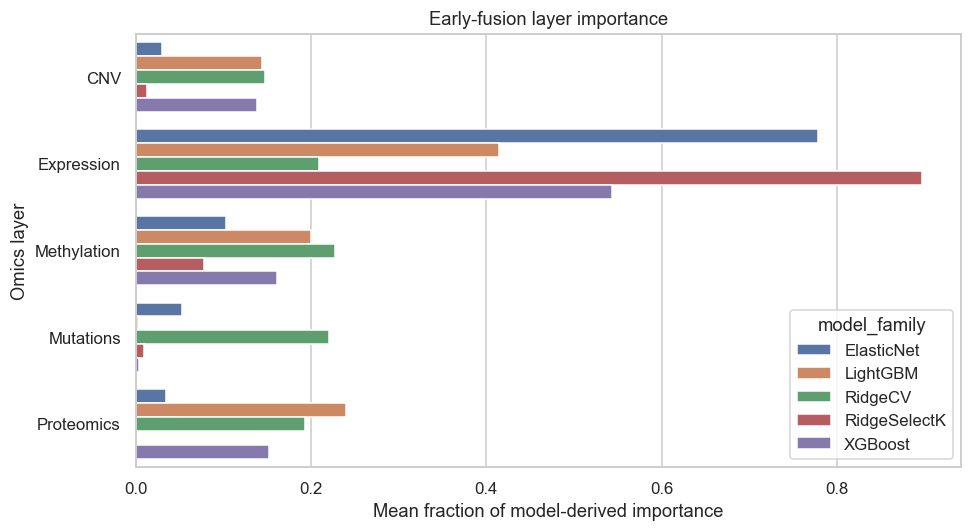

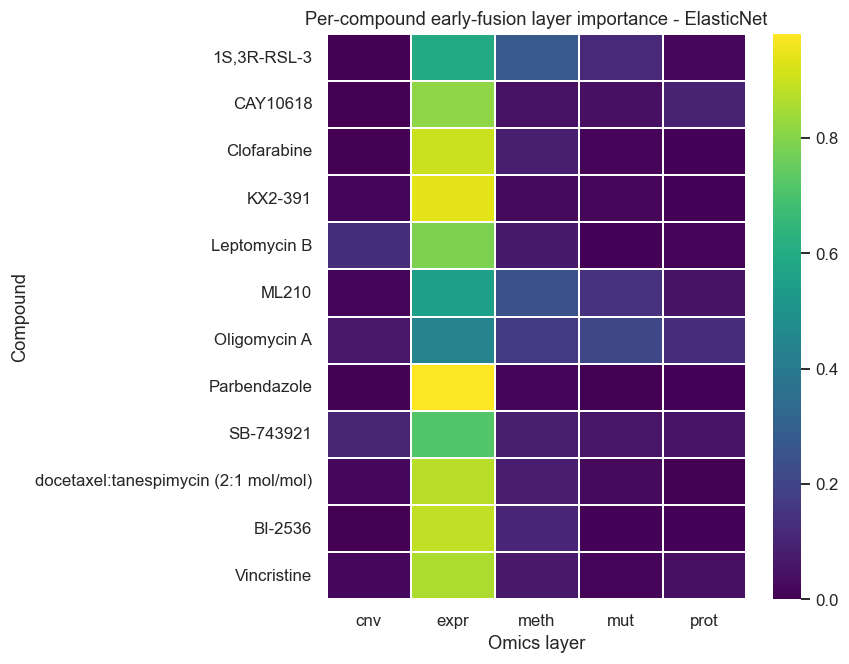

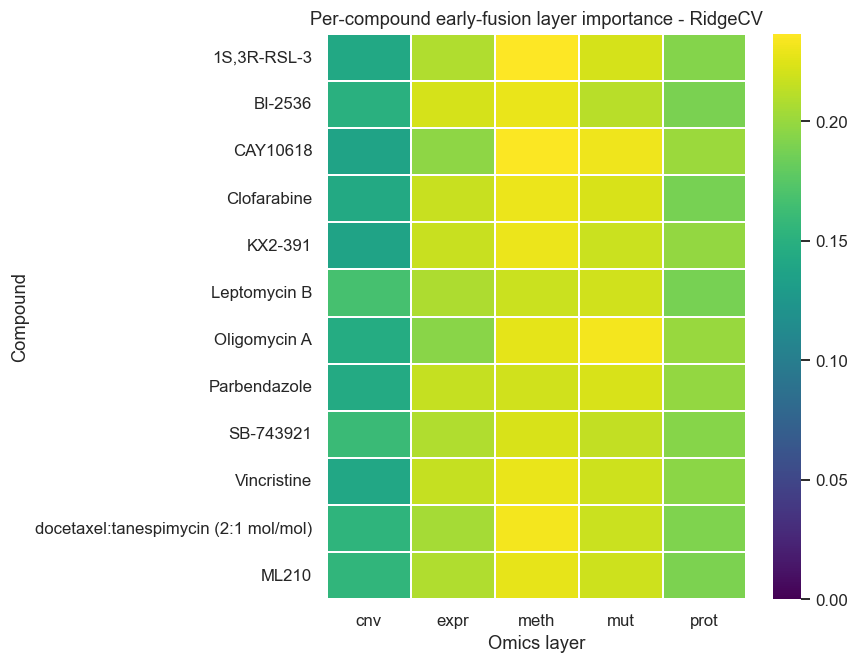

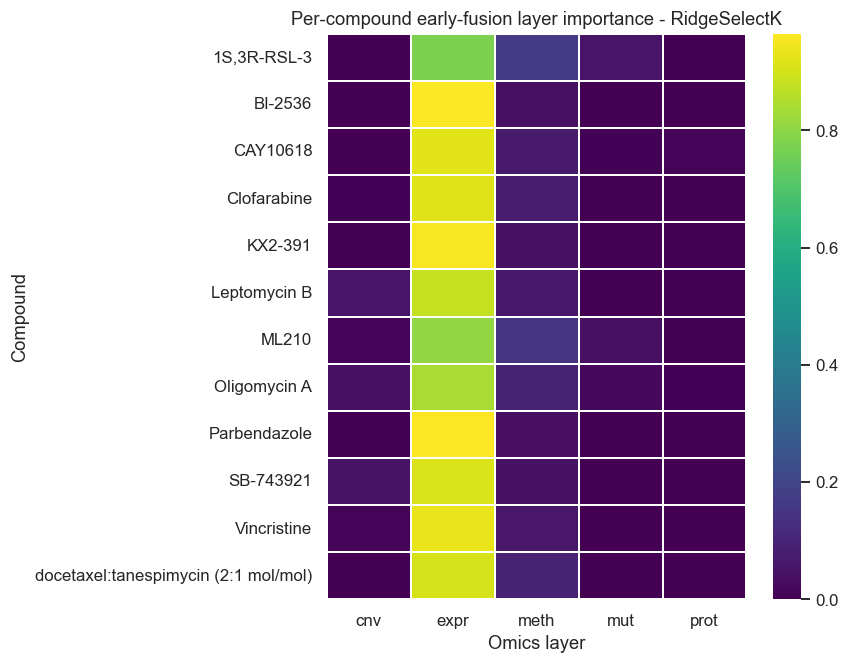

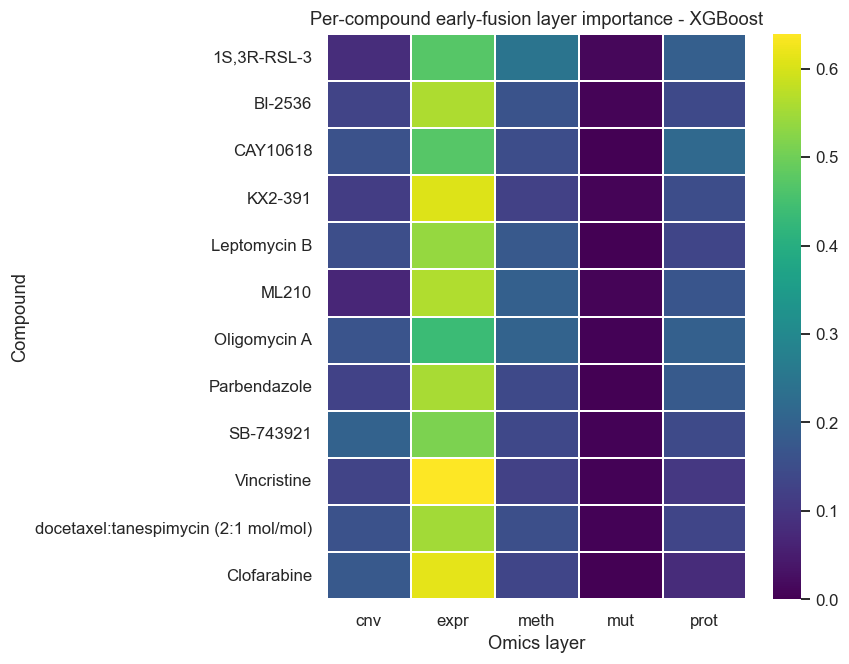

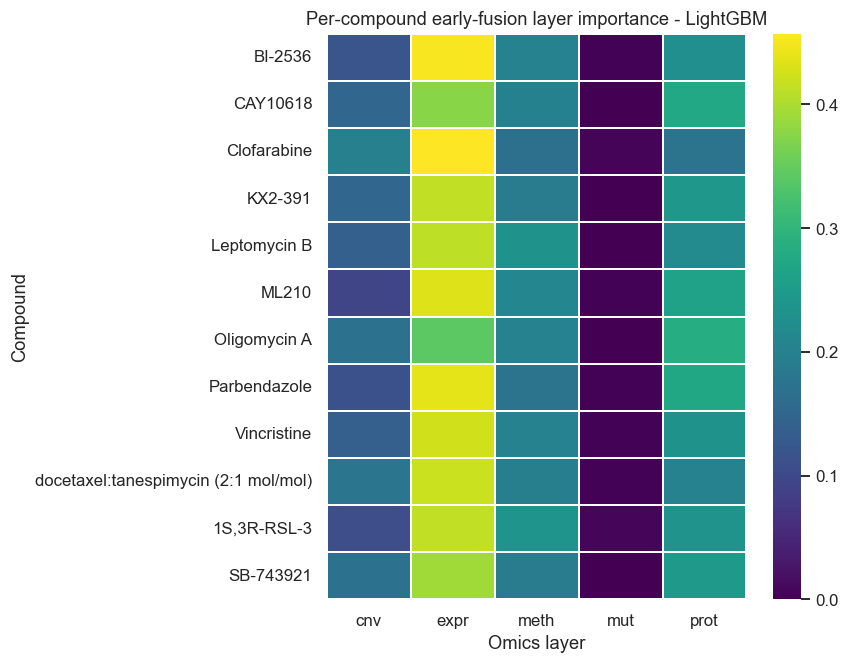

In [16]:
if feature_importance.empty or layer_importance.empty:
    print("No feature-importance records available.")
else:
    early_layer_importance = layer_importance[layer_importance["strategy"].eq("early_fusion")].copy()
    early_layer_importance["omics_layer_label"] = early_layer_importance["omics_layer"].map(LAYER_LABELS).fillna(
        early_layer_importance["omics_layer"]
    )

    mean_layer = (
        early_layer_importance.groupby(["model_family", "omics_layer", "omics_layer_label"], as_index=False)
        .agg(mean_fraction=("importance_fraction", "mean"), mean_raw_importance=("raw_importance", "mean"))
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(
        data=mean_layer,
        x="mean_fraction",
        y="omics_layer_label",
        hue="model_family",
        ax=ax,
    )
    ax.set_xlabel("Mean fraction of model-derived importance")
    ax.set_ylabel("Omics layer")
    ax.set_title("Early-fusion layer importance")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "early_fusion_layer_importance_grouped_bar.png", dpi=180, bbox_inches="tight")
    plt.show()

    for family in early_layer_importance["model_family"].unique():
        layer_pivot = early_layer_importance[early_layer_importance["model_family"] == family].pivot_table(
            index="compound",
            columns="omics_layer",
            values="importance_fraction",
            aggfunc="mean",
        )
        layer_pivot = layer_pivot.loc[layer_pivot.mean(axis=1).sort_values(ascending=False).index]
        fig_height = max(5, min(14, 0.35 * len(layer_pivot) + 2))
        fig, ax = plt.subplots(figsize=(8, fig_height))
        sns.heatmap(layer_pivot, cmap="viridis", vmin=0, annot=False, linewidths=0.25, ax=ax)
        ax.set_xlabel("Omics layer")
        ax.set_ylabel("Compound")
        ax.set_title(f"Per-compound early-fusion layer importance - {family}")
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / f"early_fusion_layer_importance_heatmap_{family.lower()}.png", dpi=180, bbox_inches="tight")
        plt.show()


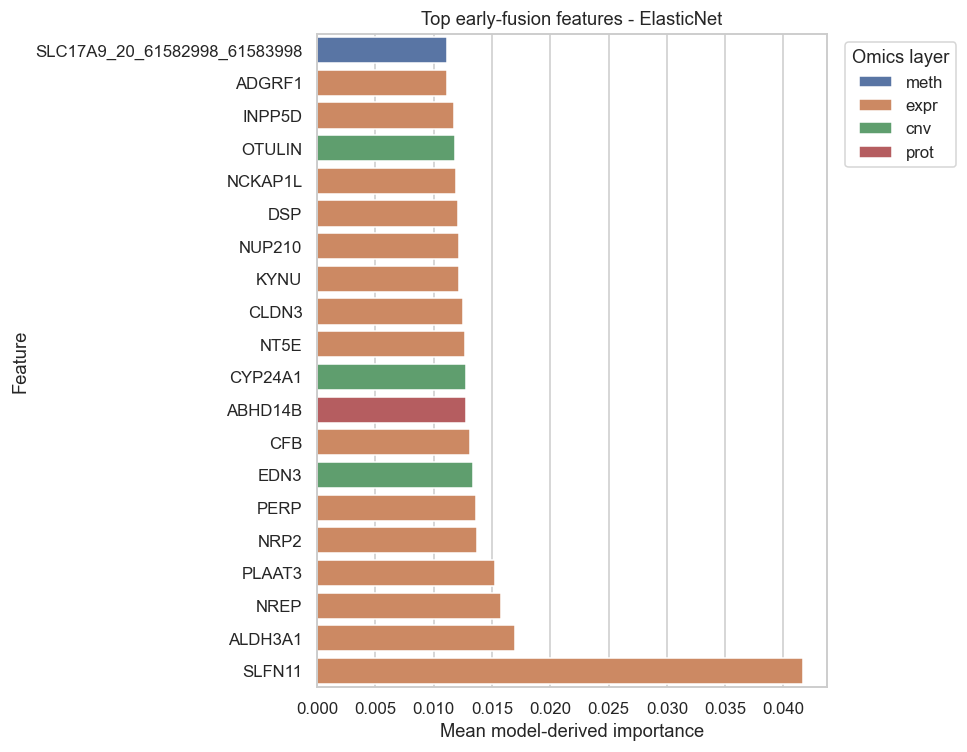

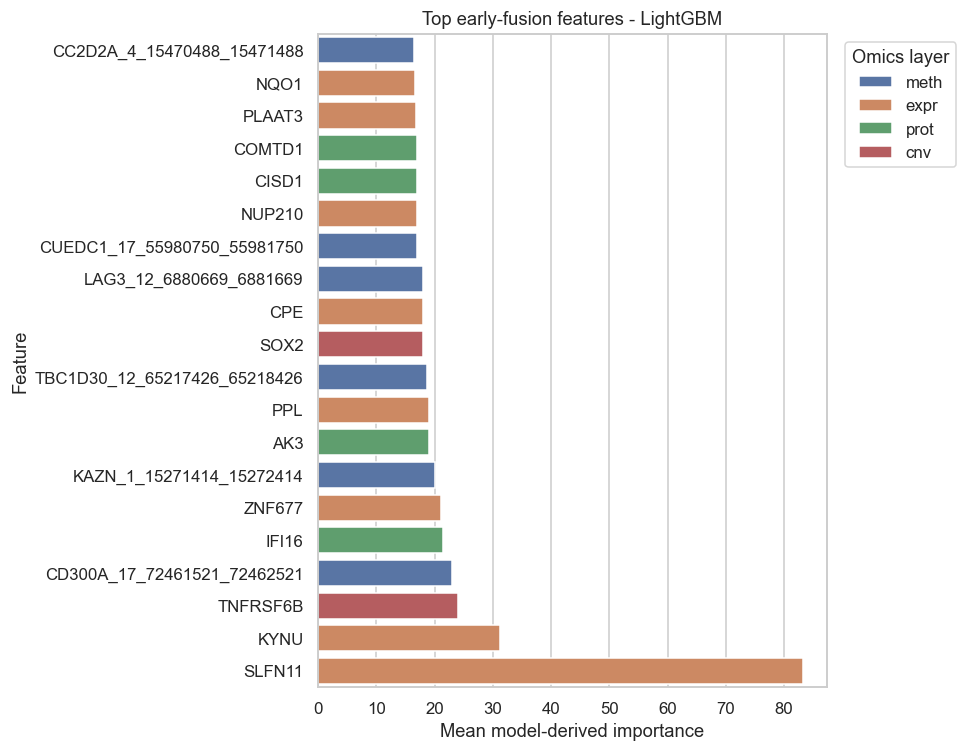

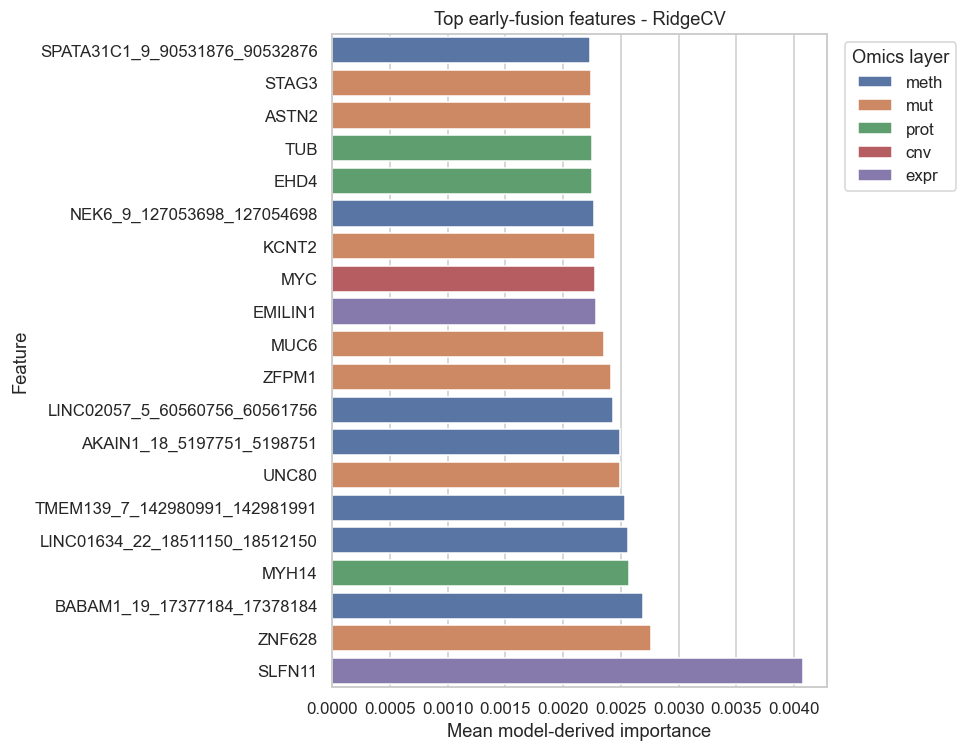

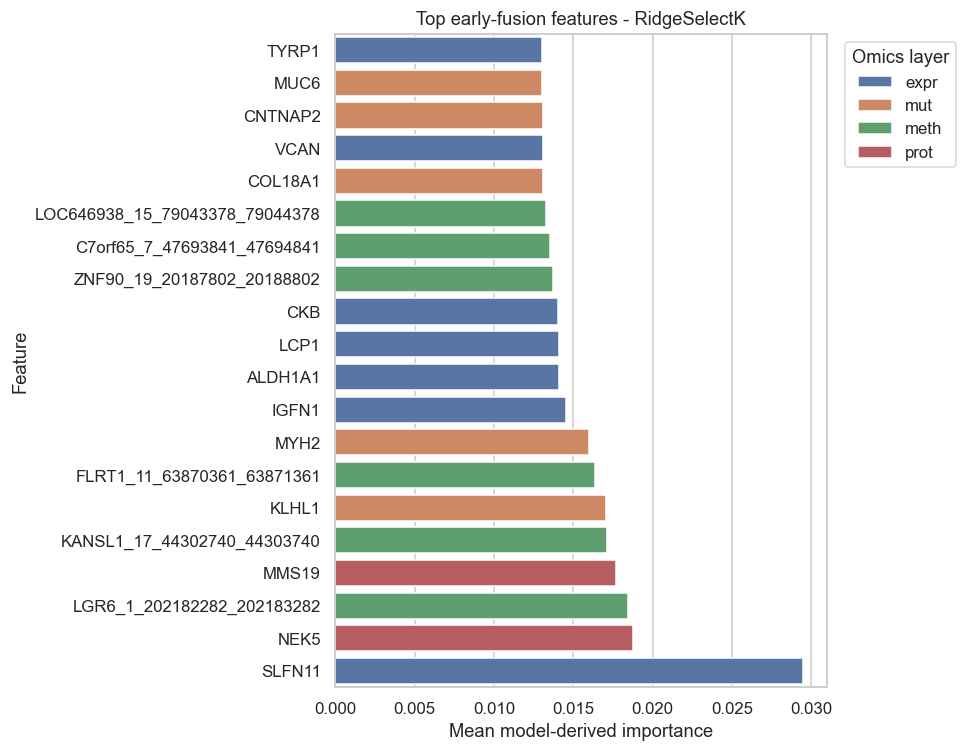

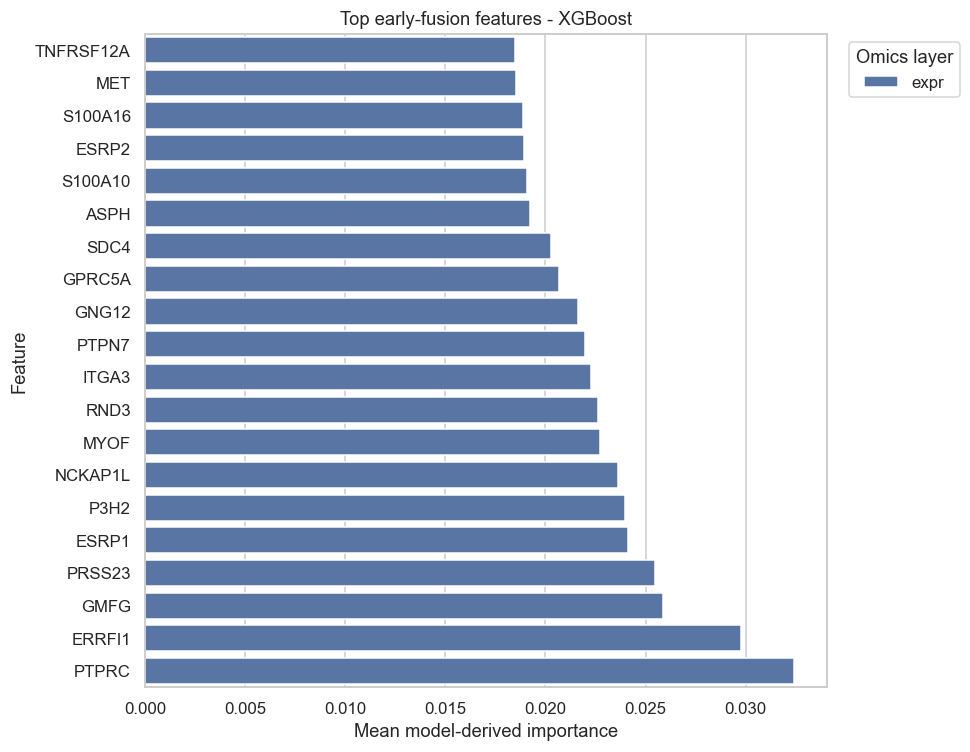

In [17]:
if feature_importance.empty:
    print("No feature-importance records available.")
else:
    early_features = feature_importance[feature_importance["strategy"].eq("early_fusion")].copy()
    early_features["feature_short"] = early_features["feature"].str.replace(r"^[a-z]+::", "", regex=True).str.slice(0, 40)

    top_features = (
        early_features.groupby(["model_family", "omics_layer", "feature", "feature_short"], as_index=False)["importance"]
        .mean()
        .sort_values(["model_family", "importance"], ascending=[True, False])
        .groupby("model_family", as_index=False)
        .head(20)
    )

    for family in top_features["model_family"].unique():
        subset = top_features[top_features["model_family"] == family].sort_values("importance", ascending=True)
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.barplot(
            data=subset,
            x="importance",
            y="feature_short",
            hue="omics_layer",
            dodge=False,
            ax=ax,
        )
        ax.set_xlabel("Mean model-derived importance")
        ax.set_ylabel("Feature")
        ax.set_title(f"Top early-fusion features - {family}")
        ax.legend(title="Omics layer", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / f"top_early_fusion_features_{family.lower()}.png", dpi=180, bbox_inches="tight")
        plt.show()


## 12. Output and validation


In [ ]:
previous_three_baseline = 0.5346017297682191
original_three = ["Vincristine", "SB-743921", "Oligomycin A"]
original_three_mean_best = float(
    best_validated[best_validated["compound"].isin(original_three)]["pearson"].mean()
)
original_three_delta = original_three_mean_best - previous_three_baseline
expected_metric_rows = int(
    len(modeling_compounds) * N_SPLITS * (len(MODEL_FAMILIES) * (len(evaluation_specs) + 1) + len(stacking_specs) + len(pathway_model_specs))
)

validation_summary = {
    "n_shared_cell_lines": int(len(common_ids)),
    "n_total_compounds": int(drug_response.shape[1]),
    "n_eligible_compounds": int(len(eligible_compounds)),
    "n_modeled_compounds": int(len(modeling_compounds)),
    "model_families": MODEL_FAMILIES,
    "run_full_modeling": bool(RUN_FULL_MODELING),
    "quick_max_features_per_layer": int(QUICK_MAX_FEATURES_PER_LAYER),
    "select_k_features": int(SELECT_K_FEATURES),
    "n_cv_metric_rows": int(len(cv_metrics)),
    "expected_cv_metric_rows": expected_metric_rows,
    "n_prediction_rows": int(len(cv_predictions)),
    "n_feature_importance_rows": int(len(feature_importance)),
    "n_layer_importance_rows": int(len(layer_importance)),
    "mean_best_validated_pearson": float(best_validated["pearson"].mean()),
    "previous_three_baseline_pearson": previous_three_baseline,
    "original_three_mean_best_pearson": original_three_mean_best,
    "original_three_delta_vs_previous": float(original_three_delta),
}

with open(RESULTS_DIR / "modeling_run_summary.json", "w") as f:
    json.dump(validation_summary, f, indent=2)

summary_table = pd.DataFrame({
    "item": validation_summary.keys(),
    "value": [str(v) for v in validation_summary.values()],
})
display(summary_table)


### Final validation checks


In [ ]:
print("Figures saved")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"  {path.name}")

assert all(df.index.equals(drug_response.index) for df in omics.values())
assert not set(drug_response.columns).intersection(feature_sets["early_fusion"].columns)
assert not set(drug_response.columns).intersection(feature_sets["signal_fusion"].columns)
assert cv_predictions["y_true"].notna().all()
assert cv_predictions["y_pred"].notna().all()
assert np.isfinite(cv_predictions["y_pred"]).all()
assert cv_metrics[["rmse", "mae"]].notna().all().all()
assert len(modeling_compounds) == (len(eligible_compounds) if RUN_FULL_MODELING else N_ANALYSIS_COMPOUNDS)
assert len(cv_metrics) == expected_metric_rows
if original_three_delta < -0.01:
    print(f"Review original three comparison, delta {original_three_delta:.4f} vs previous baseline")
else:
    print(f"Original three comparison passed, delta {original_three_delta:.4f} vs previous baseline")
for required_file in [
    "best_validated_models.csv",
    "strategy_performance_summary.csv",
    "integration_vs_single_baseline.csv",
    "pathway_module_definitions.csv",
    "pathway_module_genes.csv",
]:
    assert (RESULTS_DIR / required_file).exists(), f"Missing {required_file}"

print("Validation checks passed")
